# Workstream 3: Insurance Claims Analysis (Thailand vs Philippines)

**Objective:** 
* Analyse the relationship between WDI climate indicators and natural disaster insurance claims. 
* Comparing Thailand and Philippines.

<br> **Country Pair:** Thailand vs Philippines 
> Read `WS3_Country_Pair_Selection_Proposal docx` for systematic evaluation of all 11 ASEAN member states

<br> **Data Sources:** WDI (World Bank) + EM-DAT (CRED) + Swiss Re sigma + Munich Re NatCatSERVICE

<br> **WDI Indicators:** Same 7 final predictors from WS1/WS2, grouped by role:
- **Exposure drivers** (directly linked to disaster losses): Urban %, Forest %, GDP/cap, Population
- **Emissions drivers** (linked to long-term climate trajectory): Energy/cap, Renewable %
- **Vulnerability driver:** Agri VA %

<br> **Output:** `WS3_Panel_THA_PHL.csv`, `WS3_Protection_Gap.csv`, `WS3_Significant_Correlations.csv`

| Step | What | Output |
|------|------|--------|
| **1 Data Loading** | (A) Load WS1 imputed panel, filter to THA & PHL; <br>(B) Load & aggregate EM-DAT; <br>(C) Merge into single panel | `Panel`, `THA`, `PHL` |
| **2 Risk Profile** | (A) Disaster frequency by type; <br>(B) Economic losses timeline; <br>(C) Top-10 costliest events table | Fig 1: Disaster Frequency by Type <br> Fig 2: Economic Losses Over Time <br> Table 1: Top-10 Costliest Events |
| **3 Protection Gap** | (A) Estimate insured losses (time-varying ratios for THA); <br>(B) Protection gap chart | Fig 3: Insured vs Uninsured Losses |
| **4 WDI–Loss Linkage** | (A) Spearman correlation heatmap (7 predictors × 4 outcomes × 2 countries); <br>(B) Key findings by role; <br>(C) Scatter plots — 4 strongest associations | Fig 4: Spearman Correlation Heatmap <br> Fig 5: Scatter — Strongest Associations |
| **5 Summary** | Portfolio implications dashboard + reinsurer recommendations | Fig 6: Summary Dashboard |
| **6 Export** | Save panel, protection gap, and correlation results for WS5 | `WS3_Panel_THA_PHL.csv` <br> `WS3_Protection_Gap.csv` <br> `WS3_Significant_Correlations.csv` |

## Working Directory
Set `Drive_Path` to your local project folder. (only thing to change)
<br> All other paths derive from it.

In [1]:
from pathlib import Path
import os

## Only change this line: 
Drive_Path = Path.home() / "Desktop/MASAHKT2026/Model" 

In [2]:
# Define subdirectories
Data_Path = Drive_Path / "Data"
Code_Path = Drive_Path / "Code"
Output_Path = Drive_Path / "Output"
Output_WS1 = Output_Path / "Output_WS1"
Output_WS2 = Output_Path / "Output_WS2"
Output_WS3 = Output_Path / "Output_WS3"
Output_WS4 = Output_Path / "Output_WS4"

# Define input file name
WDI_Filename = 'WB_WDI_WIDEF.csv'
Panel_Filename = 'WS1_Panel_Imputed.csv'
EMDAT_Filename = 'EMDAT_THA_PHL.csv'
# Source note for data (Chart footnote)
WDI_Source = 'Source: World Bank WDI (Wide Format), accessed 2026-04-26' 
EMDAT_Source = 'Source: EM-DAT, CRED (Thailand & Philippines), accessed 2026-04-27'

# Create directories if they don't exist
for p in [Data_Path, Code_Path, Output_Path, Output_WS1, Output_WS2, Output_WS3, Output_WS4]:
    p.mkdir(parents=True, exist_ok=True)

## Setup
* Import libraries
* Set plotting format and colour codes
* Define constants: indicator mapping, country codes, year range

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot styling 
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'figure.facecolor': 'white',
})

Colors = {'Thailand': '#E63946', 'Philippines': '#1D3557'}
Colors_Light = {'Thailand': '#FFCDD2', 'Philippines': '#B3CDE3'}

# Country and year constants 
Country_Map = {'THA': 'Thailand', 'PHL': 'Philippines'}
Years = [str(y) for y in range(2000, 2025)]

# WDI Indicator mapping 
# - Same 7 predictors from WS1/WS2, plus emissions target and supplementary context indicators
# - Uses WB_WDI SDMX codes (matching WS1) with Short names (matching WS2 columns)
Indicator_Map = {
    # === Target (from WS2) ===
    'WB_WDI_EN_GHG_ALL_MT_CE_AR5': 'Total_GHG',
    # === 7 Final Predictors (from WS1 screening) ===
    'WB_WDI_SP_POP_TOTL':          'Population',
    'WB_WDI_NY_GDP_PCAP_PP_KD':    'GDP_Per_Capita_PPP',
    'WB_WDI_EG_USE_PCAP_KG_OE':    'Energy_Per_Capita',
    'WB_WDI_EG_FEC_RNEW_ZS':       'Renewable_%',
    'WB_WDI_SP_URB_TOTL_IN_ZS':    'Urban_%',
    'WB_WDI_AG_LND_FRST_ZS':       'Forest_%',
    'WB_WDI_NV_AGR_TOTL_ZS':       'Agri_VA_%',
    # === Supplementary context (not in WS2 model, used for descriptive comparison) ===
    'WB_WDI_EN_GHG_CO2_MT_CE_AR5': 'CO2_Total',
    'WB_WDI_NY_GDP_MKTP_CD':       'GDP_Total',
}

# Reverse lookup
Short_To_Code = {v: k for k, v in Indicator_Map.items()}

# Display names for charts 
Indicator_Names = {
    'Total_GHG':          'Total GHG (Mt CO\u2082e)',
    'Population':         'Population',
    'GDP_Per_Capita_PPP': 'GDP Per Capita (PPP)',
    'Energy_Per_Capita':  'Energy Use Per Capita',
    'Renewable_%':        'Renewable Energy (%)',
    'Urban_%':            'Urban Pop (%)',
    'Forest_%':           'Forest Area (%)',
    'Agri_VA_%':          'Agriculture VA (% GDP)',
    'CO2_Total':          'CO\u2082 Emissions (Mt CO\u2082e)',
    'GDP_Total':          'GDP (USD)',
}


# Indicator role classification (for WS3 interpretation) 
# - Grouped by how they relate to disaster losses, not emissions
Role_Map = {
    'Urban_%':            'Exposure',      # Asset concentration in hazard zones
    'Forest_%':           'Exposure',      # Natural buffer against floods/landslides
    'GDP_Per_Capita_PPP': 'Exposure',      # Economic value at risk
    'Population':         'Exposure',      # People exposed
    'Energy_Per_Capita':  'Emissions',     # Energy intensity -> emissions trajectory
    'Renewable_%':        'Emissions',     # Energy mix -> emissions trajectory
    'Agri_VA_%':          'Vulnerability', # Agricultural/rural exposure
}

# The 7 WS1/WS2 predictors (used in correlation analysis)
WS2_Predictors = list(Role_Map.keys())

print("Setup complete.")
print(f"  WS2 predictors carried forward: {len(WS2_Predictors)}")
print(f"  Role breakdown: {dict(pd.Series(Role_Map).value_counts())}")

Setup complete.
  WS2 predictors carried forward: 7
  Role breakdown: {'Exposure': 4, 'Emissions': 2, 'Vulnerability': 1}


## Step 1: Data Loading & Preparation

### Step 1(A) Load WS1 Panel Data
Load the imputed panel from WS1 (`WS1_Panel_Imputed.csv`) and filter to Thailand and Philippines. 
* Has all 7 predictors + target for 135 countries

In [4]:
# Load WS1 panel 
Panel = pd.read_csv(Data_Path / Panel_Filename)


# Filter to Thailand and Philippines
Panel = Panel[Panel['Ref_Area'].isin(['THA', 'PHL'])].copy()
Panel['Country'] = Panel['Ref_Area'].map({'THA': 'Thailand', 'PHL': 'Philippines'})

# Verify columns from WS2 are present
for col in WS2_Predictors + ['Total_GHG']:
    assert col in Panel.columns, f'Missing column: {col}'

print('=' * 60)
print('     STEP 1(A): WS1 PANEL LOADED')
print('=' * 60)
print(f'Source:     {Panel_Filename}')
print(f'Filtered:   THA + PHL = {len(Panel)} rows')
print(f'Year range: {Panel["Year"].min()}–{Panel["Year"].max()}')
print(f'Predictors: {WS2_Predictors}')

     STEP 1(A): WS1 PANEL LOADED
Source:     WS1_Panel_Imputed.csv
Filtered:   THA + PHL = 50 rows
Year range: 2000–2024
Predictors: ['Urban_%', 'Forest_%', 'GDP_Per_Capita_PPP', 'Population', 'Energy_Per_Capita', 'Renewable_%', 'Agri_VA_%']


### Step 1(B) Load & Aggregate EM-DAT Disaster Data

EM-DAT provides event-level records. We aggregate to annual level per country for merging with WDI.

**Key fields used:**
- `Total Damage, Adjusted ('000 US$)` — inflation-adjusted economic losses
- `Insured Damage ('000 US$)` — insured losses (sparse: ~11 events have data)
- `Total Deaths`, `Total Affected` — human impact
- `Disaster Type` — for type-specific analysis (flood vs storm)

In [5]:
# Load EMDAT data
EMDAT = pd.read_csv(Data_Path / EMDAT_Filename)

# Filter to natural disasters only
Nat_Types = ['Flood', 'Storm', 'Earthquake', 'Drought', 'Mass movement (wet)',
             'Volcanic activity', 'Extreme temperature', 'Wildfire', 'Mass movement (dry)']
EMDAT = EMDAT[EMDAT['Disaster Type'].isin(Nat_Types)].copy()

# Rename all columns to Title_Case with underscores
EMDAT = EMDAT.rename(columns=lambda c: c.strip().replace(' ', '_').replace("'", '').replace(',', ''))

# Rename some messy column names
EMDAT = EMDAT.rename(columns={
    'Start_Year':                              'Year',
    'Disaster_Type':                           'Disaster_Type',
    'Total_Damage_Adjusted_(000_US$)':         'Damage_Adj_000',
    'Total_Damage_(000_US$)':                  'Damage_Raw_000',
    'Insured_Damage_(000_US$)':                'Insured_000',
    'Total_Deaths':                            'Deaths',
    'Total_Affected':                          'Affected',
})

# Aggregate to annual level per country
EMDAT_Annual = EMDAT.groupby(['Country', 'Year']).agg(
    Event_Count     = ('DisNo.',        'count'),
    Total_Deaths    = ('Deaths',        'sum'),
    Total_Affected  = ('Affected',      'sum'),
    Econ_Loss_Adj_M = ('Damage_Adj_000', lambda x: x.sum() / 1e3),
    Econ_Loss_Raw_M = ('Damage_Raw_000', lambda x: x.sum() / 1e3),
    Insured_Loss_M  = ('Insured_000',    lambda x: x.sum() / 1e3),
    Flood_Count     = ('Disaster_Type',  lambda x: (x == 'Flood').sum()),
    Storm_Count     = ('Disaster_Type',  lambda x: (x == 'Storm').sum()),
    Earthquake_Count= ('Disaster_Type',  lambda x: (x == 'Earthquake').sum()),
    Other_Count     = ('Disaster_Type',  lambda x: (~x.isin(['Flood', 'Storm', 'Earthquake'])).sum()),
).reset_index()

print('=' * 60)
print('     STEP 1(B): EM-DAT DATA LOADED')
print('=' * 60)
print(f'Total EM-DAT records: {len(EMDAT)}')
print(f'  Thailand:    {len(EMDAT[EMDAT["Country"]=="Thailand"]):>4d} events')
print(f'  Philippines: {len(EMDAT[EMDAT["Country"]=="Philippines"]):>4d} events')
print(f'Annual aggregation: {len(EMDAT_Annual)} country-year records')

     STEP 1(B): EM-DAT DATA LOADED
Total EM-DAT records: 487
  Thailand:     117 events
  Philippines:  370 events
Annual aggregation: 49 country-year records


### Step 1(C) Merge WDI + EM-DAT Panel

In [6]:
# Merge 2 datasets into single one
Panel = pd.merge(Panel, EMDAT_Annual, on=['Country', 'Year'], how='left')
Panel = Panel.sort_values(['Country', 'Year']).reset_index(drop=True)

# Fill years with no disasters as 0
Disaster_Cols = ['Event_Count', 'Total_Deaths', 'Total_Affected', 'Econ_Loss_Adj_M',
                 'Econ_Loss_Raw_M', 'Insured_Loss_M', 'Flood_Count', 'Storm_Count',
                 'Earthquake_Count', 'Other_Count']
Panel[Disaster_Cols] = Panel[Disaster_Cols].fillna(0)

# Create country subsets
THA = Panel[Panel['Country'] == 'Thailand'].copy()
PHL = Panel[Panel['Country'] == 'Philippines'].copy()

print('=' * 60)
print('     STEP 1(C): PANEL MERGED')
print('=' * 60)
print(f'Final panel: {Panel.shape[0]} rows × {Panel.shape[1]} columns')
print(f'  Thailand:    {len(THA)} years | {int(THA["Event_Count"].sum()):>4d} total events | ${THA["Econ_Loss_Adj_M"].sum()/1000:.1f}B total losses')
print(f'  Philippines: {len(PHL)} years | {int(PHL["Event_Count"].sum()):>4d} total events | ${PHL["Econ_Loss_Adj_M"].sum()/1000:.1f}B total losses')

     STEP 1(C): PANEL MERGED
Final panel: 50 rows × 29 columns
  Thailand:    25 years |  117 total events | $69.2B total losses
  Philippines: 25 years |  370 total events | $33.1B total losses


In [7]:
# Delete used once list/variables 
del Disaster_Cols
# del EMDAT, EMDAT_Annual

## Step 2: Risk Profile Comparison

This section compare disaster profiles of Thailand and Philippines 
* Foundation for the reinsurer comparison.

| Dimension | Thailand | Philippines |
|-----------|----------|-------------|
| **Dominant peril** | Riverine/monsoon flooding | Typhoons (tropical cyclones) |
| **Loss profile** | Low frequency, high severity (concentrated tail risk) | High frequency, moderate severity (attritional) |
| **Insurance exposure** | Commercial/industrial (CBI) | Household/agricultural |
| **Key event** | 2011 floods: USD 46B economic, USD 15B insured | Haiyan 2013: USD 10B economic, USD 0.7B insured |

### Step 2(A) Figure 1: Disaster Frequency by Type

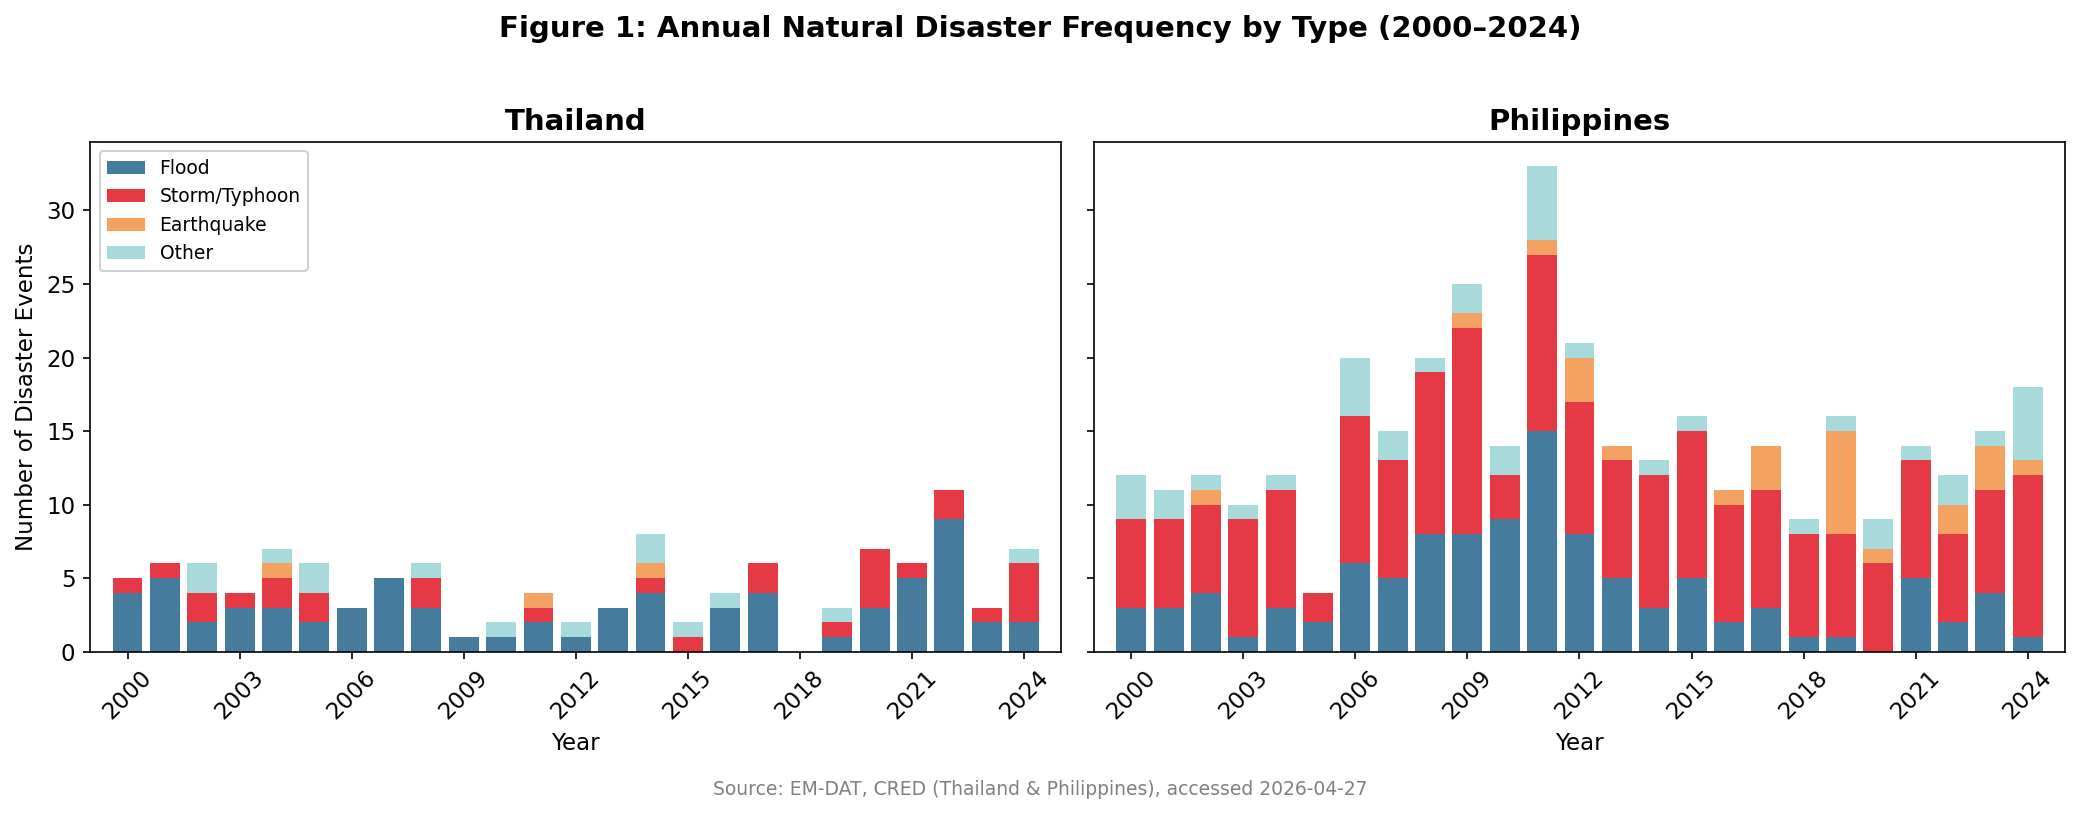

Average events/year:  Thailand 4.7  |  Philippines 14.8  (ratio: 3.2x)
Dominant peril share: Thailand floods 61%  |  Philippines storms 54%


In [8]:
# ============================================================
# FIGURE 1: Disaster Frequency Over Time (Stacked by type)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (country, sub) in zip(axes, [('Thailand', THA), ('Philippines', PHL)]):
    ax.bar(sub['Year'], sub['Flood_Count'], label='Flood', color='#457B9D', width=0.8)
    ax.bar(sub['Year'], sub['Storm_Count'], bottom=sub['Flood_Count'],
           label='Storm/Typhoon', color='#E63946', width=0.8)
    ax.bar(sub['Year'], sub['Earthquake_Count'],
           bottom=sub['Flood_Count'] + sub['Storm_Count'],
           label='Earthquake', color='#F4A261', width=0.8)
    ax.bar(sub['Year'], sub['Other_Count'],
           bottom=sub['Flood_Count'] + sub['Storm_Count'] + sub['Earthquake_Count'],
           label='Other', color='#A8DADC', width=0.8)
    ax.set_title(f'{country}', fontweight='bold', fontsize=14)
    ax.set_xlabel('Year')
    ax.set_xlim(1999, 2025)
    ax.set_xticks(range(2000, 2025, 3))
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Number of Disaster Events')
axes[0].legend(loc='upper left', fontsize=9, framealpha=0.9)
fig.suptitle('Figure 1: Annual Natural Disaster Frequency by Type (2000\u20132024)',
             fontweight='bold', fontsize=14, y=1.02)
plt.figtext(0.5, -0.02, EMDAT_Source,
            ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig(Output_WS3 / 'WS3_disaster_frequency.png')
plt.show()

# Print summary statistics
THA_Avg = THA['Event_Count'].mean()
PHL_Avg = PHL['Event_Count'].mean()
THA_Flood_Pct = THA['Flood_Count'].sum() / THA['Event_Count'].sum() * 100
PHL_Storm_Pct = PHL['Storm_Count'].sum() / PHL['Event_Count'].sum() * 100
print(f'Average events/year:  Thailand {THA_Avg:.1f}  |  Philippines {PHL_Avg:.1f}  (ratio: {PHL_Avg/THA_Avg:.1f}x)')
print(f'Dominant peril share: Thailand floods {THA_Flood_Pct:.0f}%  |  Philippines storms {PHL_Storm_Pct:.0f}%')

**Interpretation:** The Philippines experiences approximately 3x more disaster events annually than Thailand. The Philippines is dominated by storms/typhoons (54% of all events), while Thailand is dominated by floods (61%). 

This confirms the distinct hazard profile contrast that makes this pair analytically informative for the reinsurer: **different perils produce different insurance outcomes.**

### Step 2(B) Figure 2: Economic Losses Over Time

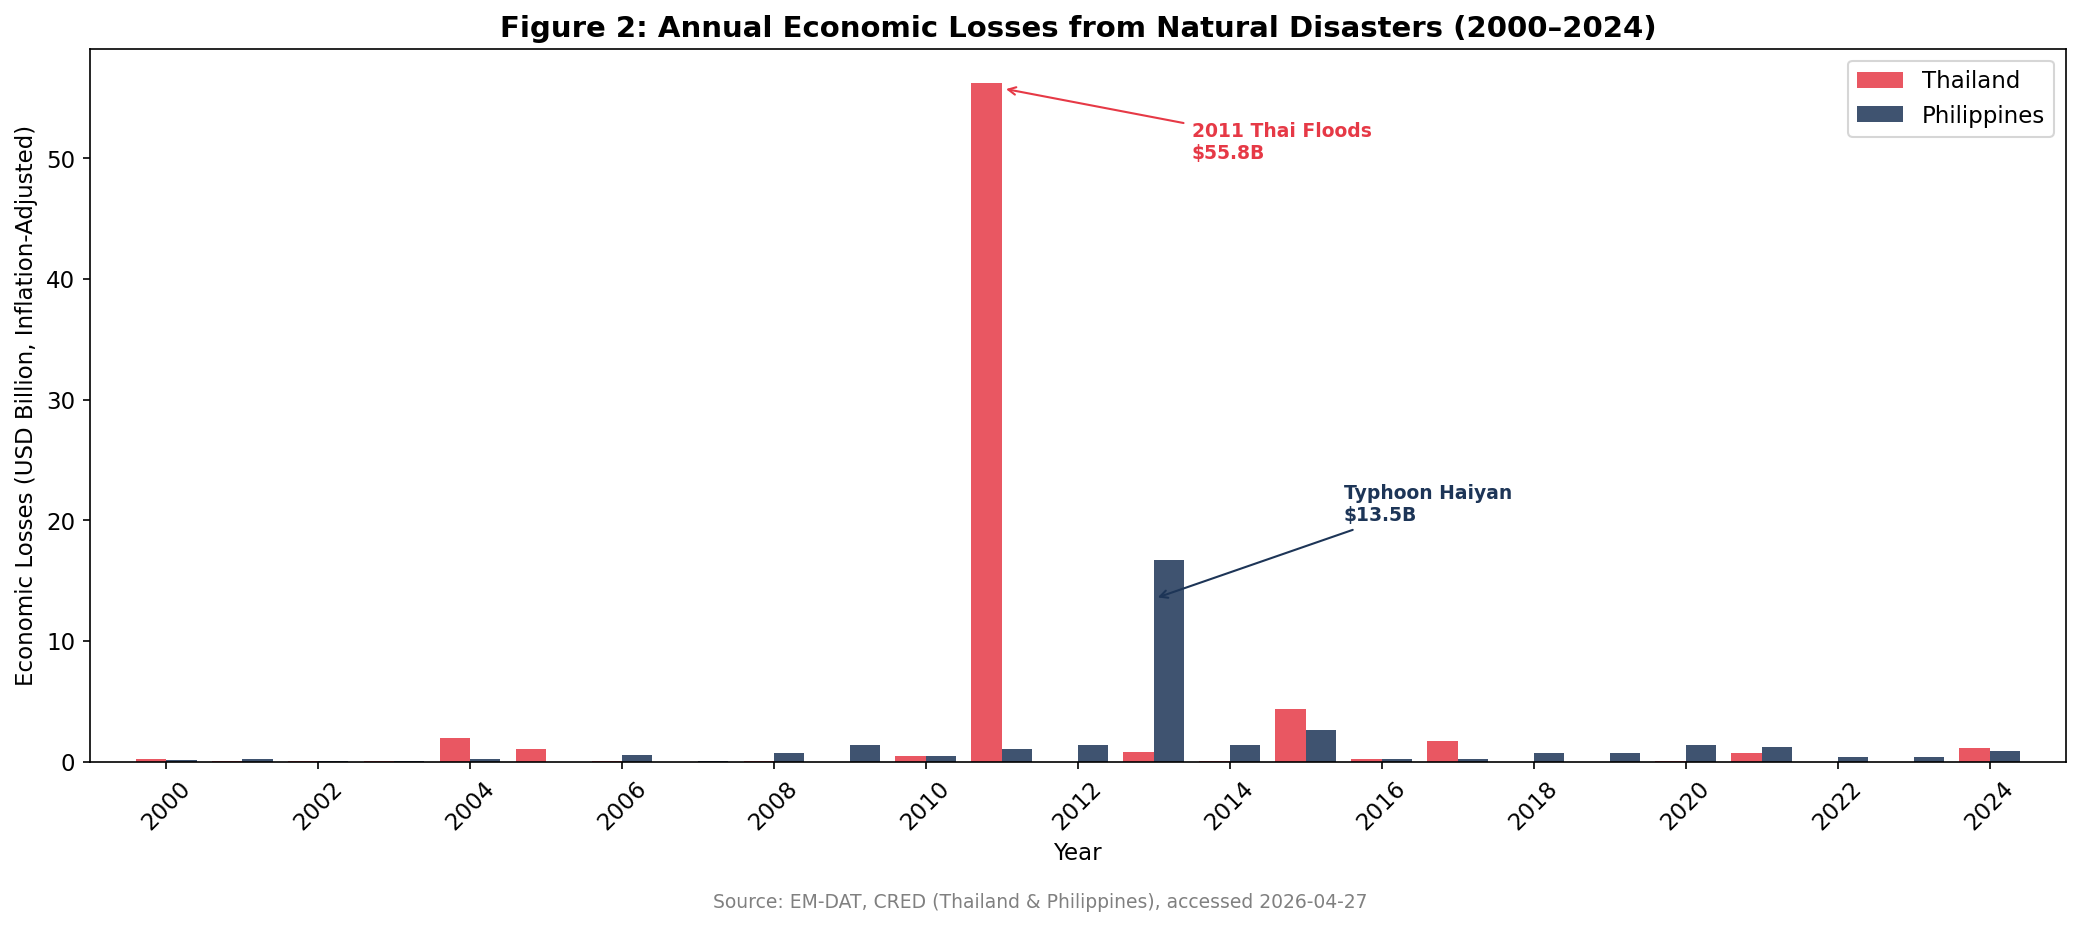

Thailand 2011 flood share of all-time losses: 81%
  -> Tail risk: single event = $56.2B out of $69.2B total


In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

for country, sub, color in [('Thailand', THA, Colors['Thailand']),
                             ('Philippines', PHL, Colors['Philippines'])]:
    ax.bar(sub['Year'] + (-0.2 if country == 'Thailand' else 0.2),
           sub['Econ_Loss_Adj_M'] / 1000, width=0.4, color=color, alpha=0.85, label=country)

# Annotate major events
ax.annotate('2011 Thai Floods\n$55.8B', xy=(2011, 55.8), xytext=(2013.5, 50),
            fontsize=9, fontweight='bold', color=Colors['Thailand'],
            arrowprops=dict(arrowstyle='->', color=Colors['Thailand']))
ax.annotate('Typhoon Haiyan\n$13.5B', xy=(2013, 13.5), xytext=(2015.5, 20),
            fontsize=9, fontweight='bold', color=Colors['Philippines'],
            arrowprops=dict(arrowstyle='->', color=Colors['Philippines']))

ax.set_xlabel('Year')
ax.set_ylabel('Economic Losses (USD Billion, Inflation-Adjusted)')
ax.set_title('Figure 2: Annual Economic Losses from Natural Disasters (2000\u20132024)',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
ax.set_xlim(1999, 2025)
ax.set_xticks(range(2000, 2025, 2))
ax.tick_params(axis='x', rotation=45)
plt.figtext(0.5, -0.02, EMDAT_Source, ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig(Output_WS3 / 'WS3_Economic_Losses.png')
plt.show()

# Print loss concentration
THA_2011 = THA[THA['Year'] == 2011]['Econ_Loss_Adj_M'].values[0]
THA_Total = THA['Econ_Loss_Adj_M'].sum()
print(f'Thailand 2011 flood share of all-time losses: {THA_2011/THA_Total*100:.0f}%')
print(f'  -> Tail risk: single event = ${THA_2011/1000:.1f}B out of ${THA_Total/1000:.1f}B total')

**Interpretation:** 

Thailand's loss profile is dominated by a single catastrophic event, *the 2011 floods ($55.8B adjusted)*, which alone accounts for 81% of all Thai disaster losses over the 25-year period. 

The Philippines also has significant tail events (Haiyan 2013, $13.5B), but shows a more distributed loss pattern with material losses in most years.

For the reinsurer, this means:
1. **Thailand = concentrated tail risk**
     - Single peak peril (flood) drives almost all exposure. 
     - Years without a major flood have negligible losses.
2. **Philippines = tail risk plus attritional base**
     - Major typhoons create peak losses, but there is also a consistent annual loss base from recurring storms. 
     - This requires both peak-peril capacity *and* aggregate/frequency management.

### Step 2(C) Table 1: Top-10 Costliest Disaster Events

An event-level table showing the largest losses for each country. 
> This is the format industry managers (Swiss Re, Munich Re) use to communicate catastrophe exposure.

In [10]:
for country in ['Thailand', 'Philippines']:
    Sub = EMDAT[EMDAT['Country'] == country].copy()
    Sub['Econ_Loss_M'] = Sub['Damage_Adj_000'] / 1e3
    Sub['Insured_M']   = Sub['Insured_000'] / 1e3
    Sub = Sub.sort_values('Econ_Loss_M', ascending=False).head(10)
    
    # Compute insured ratio where available
    Sub['Insured_Ratio_%'] = np.where(
        (Sub['Econ_Loss_M'] > 0) & (Sub['Insured_M'] > 0),
        (Sub['Insured_M'] / Sub['Econ_Loss_M'] * 100).round(1),
        np.nan
    )
    
    Display_Cols = ['Year', 'Disaster_Type', 'Event_Name', 'Econ_Loss_M', 
                    'Insured_M', 'Insured_Ratio_%', 'Deaths']
    Display_Cols = [c for c in Display_Cols if c in Sub.columns]
    
    print(f'\n{"="*72}')
    print(f'  TABLE 1: Top-10 Costliest Events — {country}')
    print(f'{"="*72}')
    print(Sub[Display_Cols].to_string(index=False))

print('\nNote: Insured loss data available for only ~11 events across both countries.')
print('Protection gap estimates in Step 3 use published aggregate ratios instead.')


  TABLE 1: Top-10 Costliest Events — Thailand
 Year Disaster_Type              Event_Name  Econ_Loss_M  Insured_M  Insured_Ratio_%  Deaths
 2011         Flood                     NaN    55781.997    10000.0             17.9   813.0
 2015       Drought                     NaN     4367.507        NaN              NaN     NaN
 2004    Earthquake                     NaN     1660.755      250.0             15.1  8345.0
 2017         Flood                     NaN     1279.738        NaN              NaN    96.0
 2024         Storm Typhoon 'Yagi' (Enteng)      904.000        NaN              NaN    45.0
 2021         Flood                     NaN      684.173        NaN              NaN    10.0
 2005       Drought                     NaN      674.629        NaN              NaN     NaN
 2013         Flood                     NaN      649.038        NaN              NaN    61.0
 2010         Flood                     NaN      477.606        NaN              NaN   258.0
 2011         Flood    

In [11]:
# Delete used-once variables 
del THA_Avg, PHL_Avg, THA_Flood_Pct, PHL_Storm_Pct
del THA_2011, THA_Total, Sub, Display_Cols

## Step 3: Protection Gap Analysis

**Protection gap**: 
* This is share of economic losses not covered by insurance is the central financial metric for the reinsurer. 
* It quantifies both **current exposure** (uninsured losses that could become insured) and **market opportunity** (addressable premium growth).

**Methodology:** EM-DAT records insured losses for only ~11 events. We therefore apply published aggregate insured ratios from Swiss Re sigma and Munich Re NatCatSERVICE to EM-DAT economic losses. Key event-specific overrides are applied where published insured figures exist.

**Time-varying approach:** Thailand's insurance landscape changed fundamentally after the 2011 floods — flood coverage was unbundled from industrial all-risk policies, premiums doubled/tripled, and excess-of-loss reinsurance rates increased 500–1,000% (A.M. Best, 2012). 
> We therefore use different insured ratios pre- and post-2011.

In [12]:
# ============================================================
#    STEP 3: PROTECTION GAP ESTIMATION
# ============================================================
# Insured ratios from industry sources:
#   Thailand pre-2011:  ~8%  (limited flood coverage in standard policies)
#   Thailand 2011:      32.6% ($15B / $46B — Swiss Re, 2021) — industrial estates
#   Thailand post-2011: ~12% (post-reform, higher flood awareness — Swiss Re sigma)
#   Philippines:        ~3%  baseline (Munich Re, MAPFRE Economics 2025)
#   Philippines Haiyan: 7%   ($700M / $10B — EM-DAT)

THA_Gap = THA.copy()
PHL_Gap = PHL.copy()

# Thailand: time-varying insured ratio
THA_Gap['Insured_Ratio'] = np.where(THA_Gap['Year'] < 2011, 0.08, 0.12)
THA_Gap['Insured_Est_M'] = THA_Gap['Econ_Loss_Adj_M'] * THA_Gap['Insured_Ratio']
# Override with known event-specific values
THA_Gap.loc[THA_Gap['Year'] == 2011, 'Insured_Est_M'] = 15000  # Swiss Re, 2021
THA_Gap.loc[THA_Gap['Year'] == 2004, 'Insured_Est_M'] = 250    # Tsunami portion
THA_Gap['Uninsured_M'] = (THA_Gap['Econ_Loss_Adj_M'] - THA_Gap['Insured_Est_M']).clip(lower=0)

# Philippines: baseline ratio with Haiyan override
PHL_Gap['Insured_Ratio'] = 0.03
PHL_Gap['Insured_Est_M'] = PHL_Gap['Econ_Loss_Adj_M'] * PHL_Gap['Insured_Ratio']
PHL_Gap.loc[PHL_Gap['Year'] == 2013, 'Insured_Est_M'] = 700    # EM-DAT / Munich Re
PHL_Gap['Uninsured_M'] = (PHL_Gap['Econ_Loss_Adj_M'] - PHL_Gap['Insured_Est_M']).clip(lower=0)

# ── Summary statistics ────────────────────────────────────────
print('=' * 60)
print('     STEP 3: PROTECTION GAP SUMMARY')
print('=' * 60)
for label, sub in [('Thailand', THA_Gap), ('Philippines', PHL_Gap)]:
    Total_Econ = sub['Econ_Loss_Adj_M'].sum()
    Total_Ins  = sub['Insured_Est_M'].sum()
    Gap_Pct    = (1 - Total_Ins / Total_Econ) * 100 if Total_Econ > 0 else 0
    print(f'  {label}:')
    print(f'    Total economic losses: ${Total_Econ/1000:.1f}B')
    print(f'    Est. insured losses:   ${Total_Ins/1000:.1f}B')
    print(f'    Protection gap:        {Gap_Pct:.0f}%')
    print()

# Thailand pre/post-2011 breakdown
THA_Pre  = THA_Gap[THA_Gap['Year'] < 2011]
THA_Post = THA_Gap[THA_Gap['Year'] >= 2012]
for label, sub in [('Pre-2011', THA_Pre), ('Post-2011', THA_Post)]:
    Te = sub['Econ_Loss_Adj_M'].sum()
    Ti = sub['Insured_Est_M'].sum()
    Gp = (1 - Ti / Te) * 100 if Te > 0 else 0
    print(f'  Thailand {label}: gap = {Gp:.0f}% (${Te/1000:.1f}B econ / ${Ti/1000:.1f}B insured)')

     STEP 3: PROTECTION GAP SUMMARY
  Thailand:
    Total economic losses: $69.2B
    Est. insured losses:   $16.5B
    Protection gap:        76%

  Philippines:
    Total economic losses: $33.1B
    Est. insured losses:   $1.2B
    Protection gap:        96%

  Thailand Pre-2011: gap = 90% ($3.9B econ / $0.4B insured)
  Thailand Post-2011: gap = 88% ($9.0B econ / $1.1B insured)


### Figure 3: Protection Gap (Insured vs Uninsured Losses)

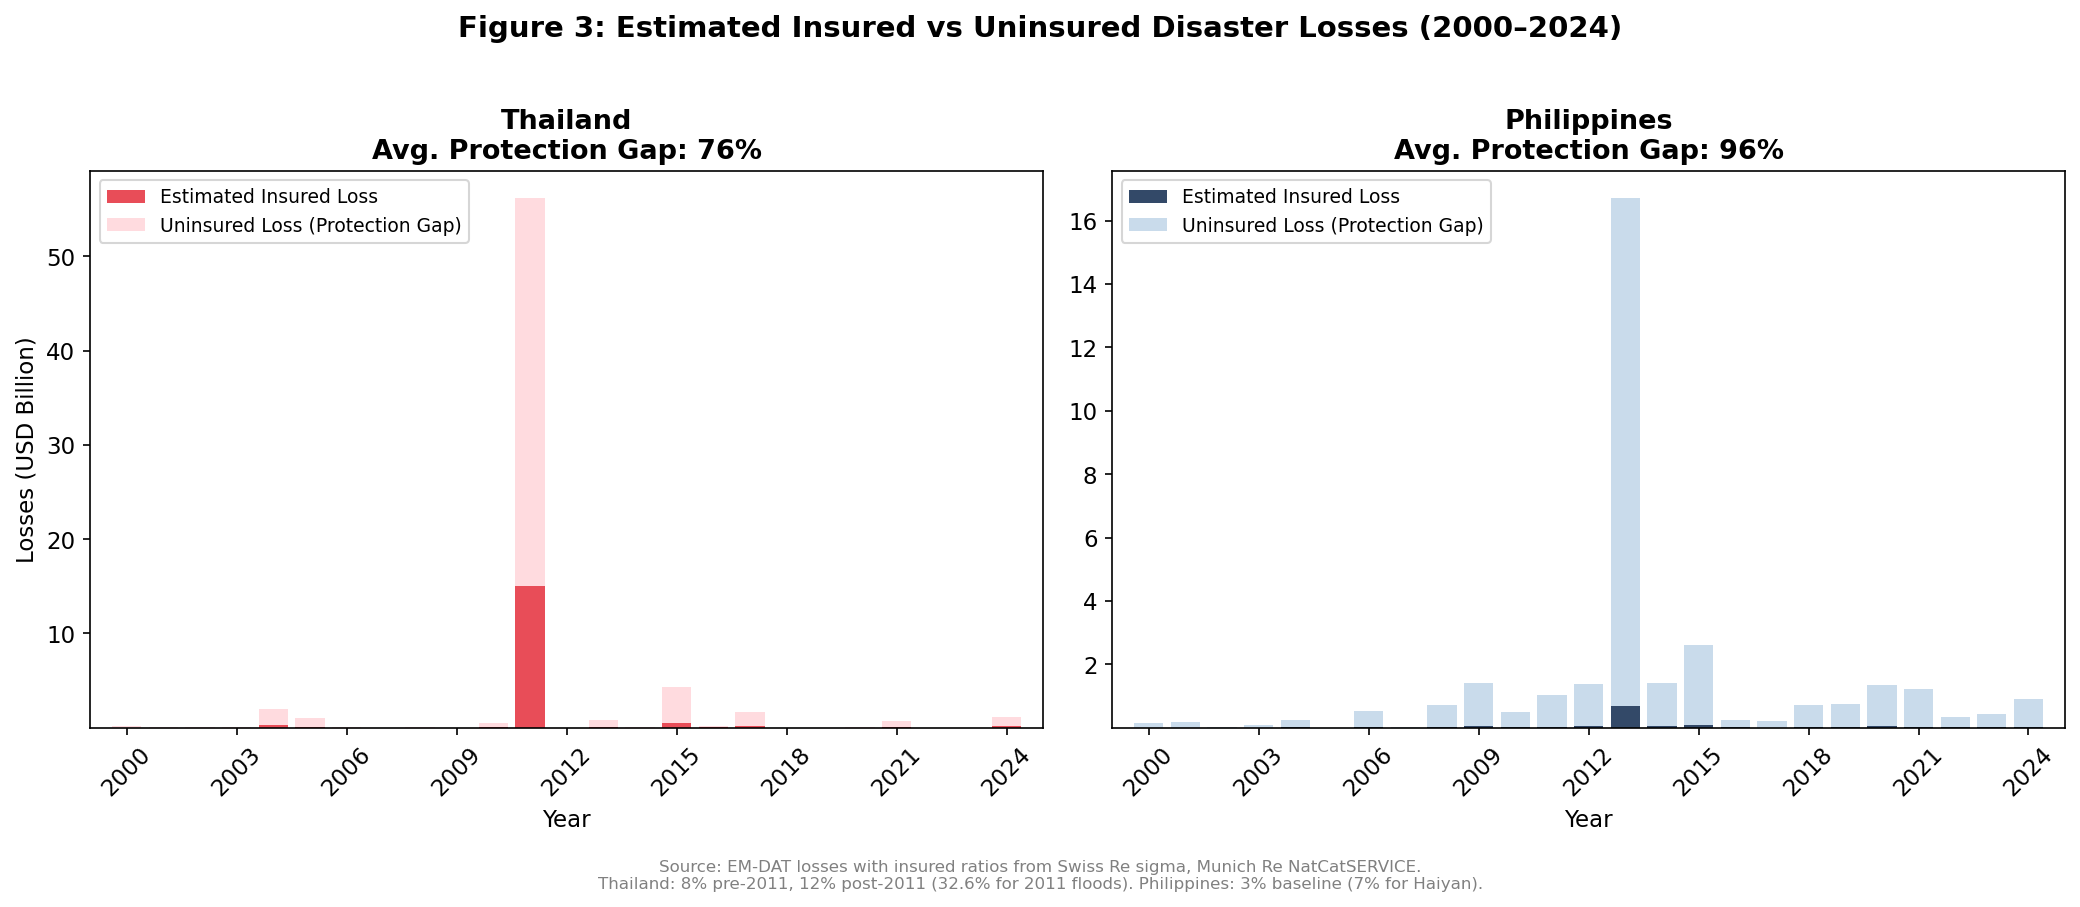

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

for ax, (country, sub, color, color_l) in zip(axes, [
    ('Thailand', THA_Gap, Colors['Thailand'], Colors_Light['Thailand']),
    ('Philippines', PHL_Gap, Colors['Philippines'], Colors_Light['Philippines'])
]):
    ax.bar(sub['Year'], sub['Insured_Est_M'] / 1000, color=color, alpha=0.9,
           label='Estimated Insured Loss')
    ax.bar(sub['Year'], sub['Uninsured_M'] / 1000, bottom=sub['Insured_Est_M'] / 1000,
           color=color_l, alpha=0.7, label='Uninsured Loss (Protection Gap)')
    
    Total_Econ = sub['Econ_Loss_Adj_M'].sum()
    Total_Ins  = sub['Insured_Est_M'].sum()
    Gap_Pct    = (1 - Total_Ins / Total_Econ) * 100 if Total_Econ > 0 else 0
    ax.set_title(f'{country}\nAvg. Protection Gap: {Gap_Pct:.0f}%', fontweight='bold', fontsize=13)
    ax.set_xlabel('Year')
    ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim(1999, 2025)
    ax.set_xticks(range(2000, 2025, 3))
    ax.tick_params(axis='x', rotation=45)

axes[0].set_ylabel('Losses (USD Billion)')
fig.suptitle('Figure 3: Estimated Insured vs Uninsured Disaster Losses (2000\u20132024)',
             fontweight='bold', fontsize=14, y=1.02)
plt.figtext(0.5, -0.04,
    'Source: EM-DAT losses with insured ratios from Swiss Re sigma, Munich Re NatCatSERVICE.\n'
    'Thailand: 8% pre-2011, 12% post-2011 (32.6% for 2011 floods). Philippines: 3% baseline (7% for Haiyan).',
    ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(Output_WS3 / 'WS3_Protection_Gap.png')
plt.show()

**Interpretation:**
1. **Thailand (76% gap):** 
    * Driven almost entirely by the 2011 flood event where industrial all-risk policies absorbed $15B. 
    * Pre-2011 gap exceeds 90%; post-2011 reforms improved but did not close the gap. 
    * Thailand's protection gap is *episodic*, it narrows only when major commercial/industrial losses trigger claims.

2. **Philippines (96% gap):** 
    * Reflects chronically low insurance penetration (1.85% in Q3 2025). 
    * Fewer than 20% of Filipino households carry disaster-related property insurance. 
    * The OECD in February 2026 recommended mandatory home insurance, a potential inflection point.

**Reinsurer implication:** 
* Thailand presents episodic reinsurance exposure concentrated in industrial estates. 
* The Philippines presents a structural underinsurance problem where the addressable market is growing (GWP projected at 11.5% CAGR through 2030) but take-up remains low.

In [14]:
# Delete used-once variables from Step 3
del Total_Econ, Total_Ins, Gap_Pct, Te, Ti, Gp
del THA_Pre, THA_Post

## Step 4: WDI–Loss Linkage Analysis

This section tests whether the **same 7 indicators from WS1/WS2** are statistically associated with disaster outcomes. 

> The key insight is that these indicators serve **different roles** in WS2 (predicting emissions) versus WS3 (explaining disaster losses):

| Role in WS3 | Indicators | Mechanism |
|-------------|-----------|-----------|
| **Exposure drivers** | Urban %, Forest %, GDP/cap, Population | Directly linked to disaster losses: more people and assets in hazard zones, fewer natural buffers |
| **Emissions drivers** | Energy/cap, Renewable % | Linked to long-term climate trajectory; no direct mechanism for individual disaster events |
| **Vulnerability driver** | Agri VA % | Agricultural economies have more uninsured rural exposure |

**Expected finding:** Exposure drivers should show stronger correlations with disaster outcomes than emissions drivers. This is because the transmission from emissions to disasters operates over decades and globally, while exposure accumulation is local and immediate.

**Method:** Spearman rank correlation (robust to the 2011 Thai flood outlier).

### Step 4(A) Figure 4: Correlation Heatmap (7 WS2 Predictors vs Disaster Outcomes)

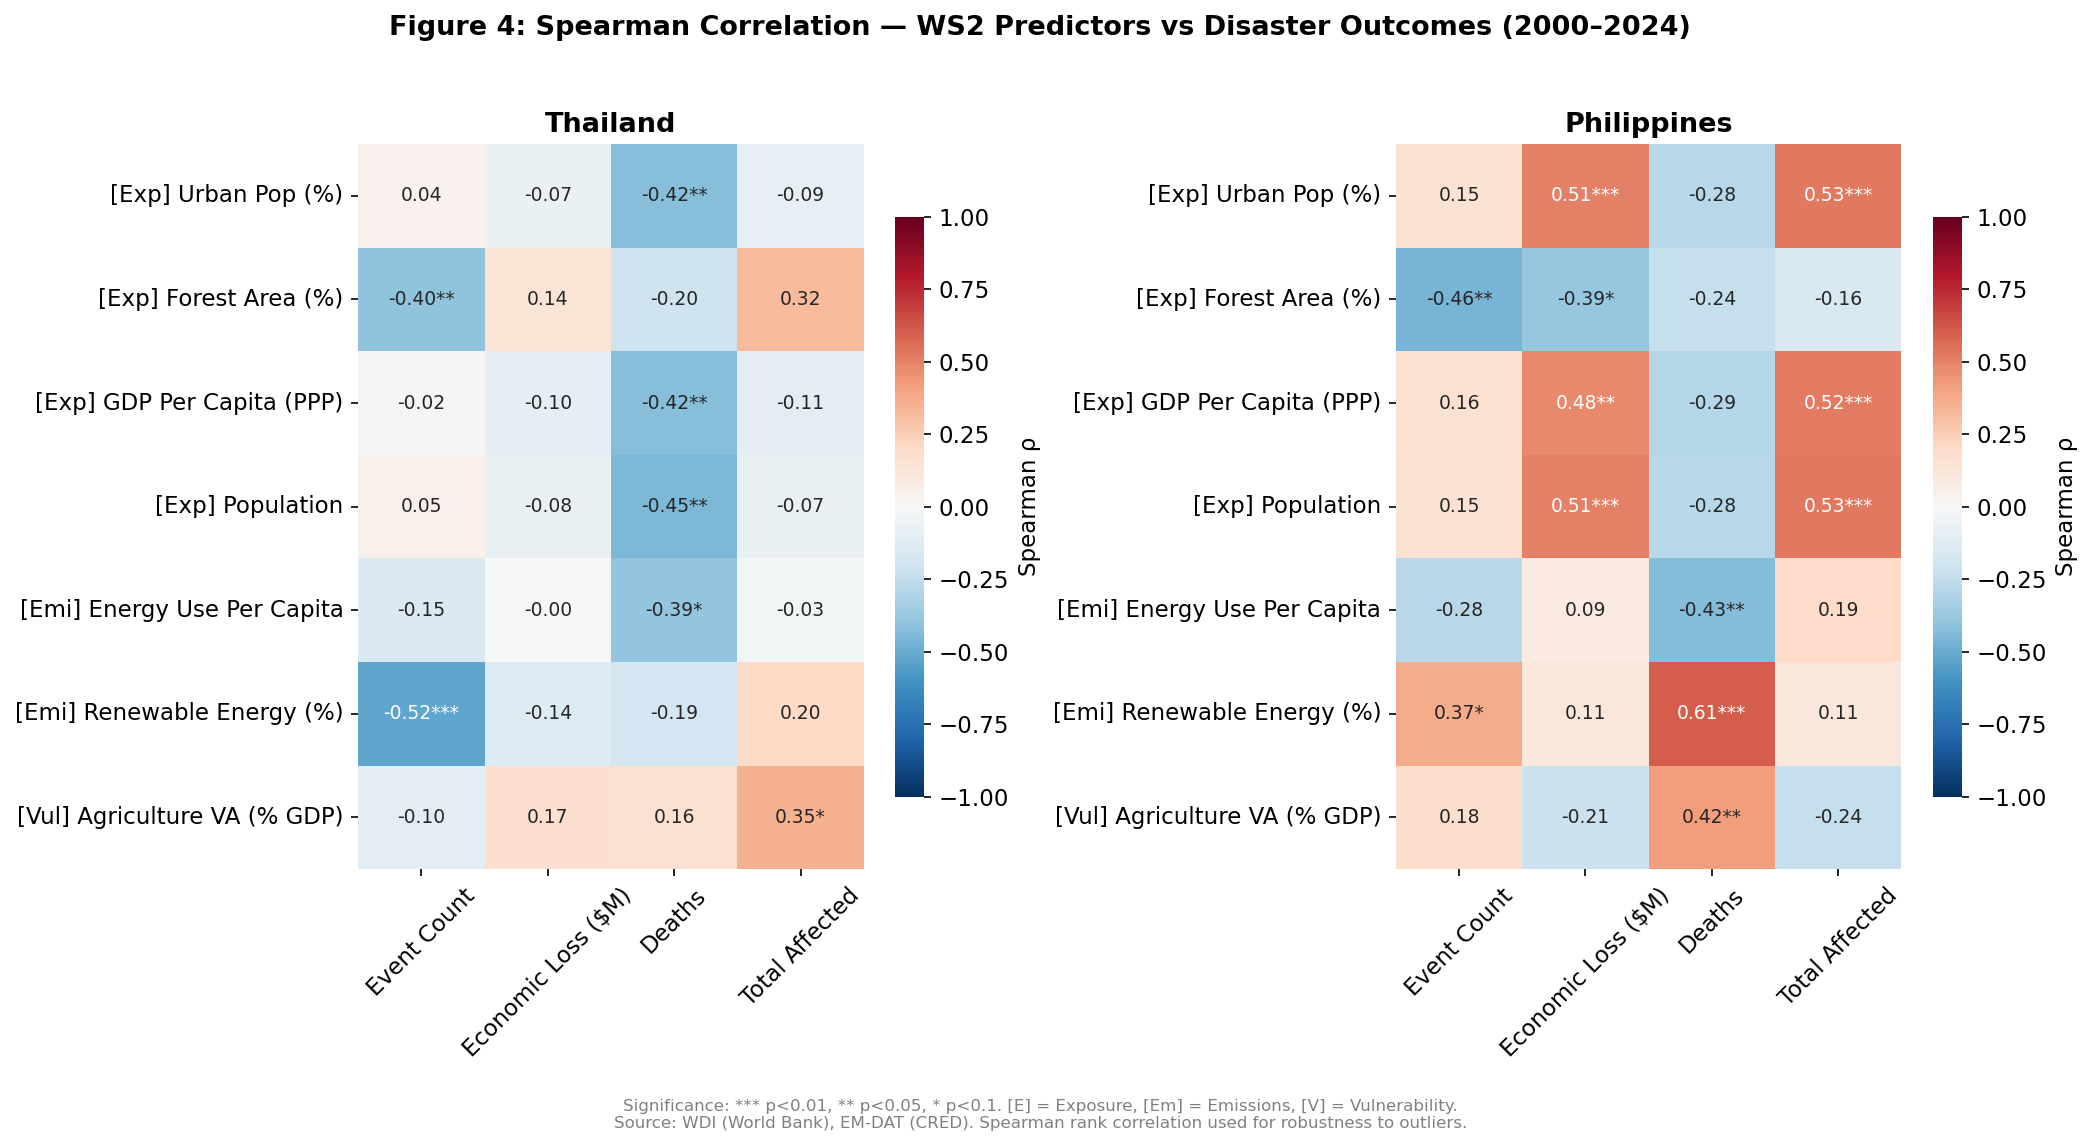

In [15]:
WDI_Cols   = WS2_Predictors  # Same 7 from WS1/WS2
WDI_Labels = [Indicator_Names[c] for c in WDI_Cols]

# Add role prefix for visual grouping
Role_Prefix = {
    'Exposure':      '[Exp]',
    'Emissions':     '[Emi]',
    'Vulnerability': '[Vul]',
}

WDI_Labels_Role = []
for c in WDI_Cols:
    Role = Role_Map[c]
    Name = Indicator_Names[c]
    WDI_Labels_Role.append(f'{Role_Prefix[Role]} {Name}')

Outcome_Cols   = ['Event_Count', 'Econ_Loss_Adj_M', 'Total_Deaths', 'Total_Affected']
Outcome_Labels = ['Event Count', 'Economic Loss ($M)', 'Deaths', 'Total Affected']

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
Sig_Results = []

for ax, country in zip(axes, ['Thailand', 'Philippines']):
    Sub = Panel[Panel['Country'] == country]
    Corr_Data = np.zeros((len(WDI_Cols), len(Outcome_Cols)))
    Pval_Data = np.zeros((len(WDI_Cols), len(Outcome_Cols)))
    
    for i, wdi_c in enumerate(WDI_Cols):
        for j, out_c in enumerate(Outcome_Cols):
            Valid = Sub[[wdi_c, out_c]].dropna()
            if len(Valid) >= 5:
                r, p = stats.spearmanr(Valid[wdi_c], Valid[out_c])
                Corr_Data[i, j] = r
                Pval_Data[i, j] = p
            else:
                Corr_Data[i, j] = np.nan
                Pval_Data[i, j] = 1.0
    
    Corr_Df = pd.DataFrame(Corr_Data, index=WDI_Labels_Role, columns=Outcome_Labels)
    Annot   = np.empty_like(Corr_Data, dtype=object)
    for i in range(Corr_Data.shape[0]):
        for j in range(Corr_Data.shape[1]):
            v, p = Corr_Data[i, j], Pval_Data[i, j]
            Star = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
            Annot[i, j] = f'{v:.2f}{Star}'
            if p < 0.05:
                Sig_Results.append({
                    'Country': country, 'Indicator': Indicator_Names[WDI_Cols[i]],
                    'Role': Role_Map[WDI_Cols[i]], 'Outcome': Outcome_Labels[j],
                    'Rho': v, 'P_Value': p
                })
    
    sns.heatmap(Corr_Df, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                annot=Annot, fmt='', annot_kws={'size': 9},
                cbar_kws={'shrink': 0.8, 'label': 'Spearman \u03c1'})
    ax.set_title(f'{country}', fontweight='bold', fontsize=13)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle('Figure 4: Spearman Correlation \u2014 WS2 Predictors vs Disaster Outcomes (2000\u20132024)',
             fontweight='bold', fontsize=13, y=1.02)
plt.figtext(0.5, -0.04,
    'Significance: *** p<0.01, ** p<0.05, * p<0.1. [E] = Exposure, [Em] = Emissions, [V] = Vulnerability.\n'
    'Source: WDI (World Bank), EM-DAT (CRED). Spearman rank correlation used for robustness to outliers.',
    ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(Output_WS3 / 'WS3_Correlation_Heatmap.png')
plt.show()

In [16]:
# Print significant results grouped by role
print('\nStatistically significant correlations (p<0.05):')
Sig_Df = pd.DataFrame(Sig_Results)
if len(Sig_Df) > 0:
    for role in ['Exposure', 'Emissions', 'Vulnerability']:
        Role_Sig = Sig_Df[Sig_Df['Role'] == role]
        if len(Role_Sig) > 0:
            print(f'\n  {role} drivers:')
            for _, row in Role_Sig.iterrows():
                print(f'    {row["Country"]}: {row["Indicator"]} vs {row["Outcome"]}: ρ={row["Rho"]:.3f}, p={row["P_Value"]:.4f}')

    # Summary by role — normalised per predictor for fair comparison
    Predictor_Counts = {'Exposure': 4, 'Emissions': 2, 'Vulnerability': 1}
    N_Total = len(Sig_Df)


Statistically significant correlations (p<0.05):

  Exposure drivers:
    Thailand: Urban Pop (%) vs Deaths: ρ=-0.422, p=0.0354
    Thailand: Forest Area (%) vs Event Count: ρ=-0.399, p=0.0484
    Thailand: GDP Per Capita (PPP) vs Deaths: ρ=-0.422, p=0.0356
    Thailand: Population vs Deaths: ρ=-0.446, p=0.0254
    Philippines: Urban Pop (%) vs Economic Loss ($M): ρ=0.505, p=0.0100
    Philippines: Urban Pop (%) vs Total Affected: ρ=0.531, p=0.0063
    Philippines: Forest Area (%) vs Event Count: ρ=-0.462, p=0.0200
    Philippines: GDP Per Capita (PPP) vs Economic Loss ($M): ρ=0.477, p=0.0159
    Philippines: GDP Per Capita (PPP) vs Total Affected: ρ=0.519, p=0.0078
    Philippines: Population vs Economic Loss ($M): ρ=0.505, p=0.0100
    Philippines: Population vs Total Affected: ρ=0.531, p=0.0063

  Emissions drivers:
    Thailand: Renewable Energy (%) vs Event Count: ρ=-0.525, p=0.0071
    Philippines: Energy Use Per Capita vs Deaths: ρ=-0.435, p=0.0299
    Philippines: Renewable En

In [17]:

print(f'\n{"="*60}')
print(f'  ROLE SUMMARY (normalised per predictor)')
print(f'{"="*60}')
print(f'  Total significant indicator-outcome pairs: {N_Total} out of 56')
print(f'  {"Role":<22s} {"Pairs":>5s}   {"Predictors":>10s}   {"Avg per predictor":>18s}')
print(f'  {"-"*22} {"-"*5}   {"-"*10}   {"-"*18}')
for role in ['Exposure', 'Emissions', 'Vulnerability']:
    N = len(Sig_Df[Sig_Df['Role'] == role])
    P = Predictor_Counts[role]
    print(f'  {role:<22s} {N:>5d}   {P:>10d}   {N/P:>18.1f}')
print(f'\n  Even after adjusting for predictor count, exposure drivers')
print(f'  produce the most significant signals per predictor.')


  ROLE SUMMARY (normalised per predictor)
  Total significant indicator-outcome pairs: 15 out of 56
  Role                   Pairs   Predictors    Avg per predictor
  ---------------------- -----   ----------   ------------------
  Exposure                  11            4                  2.8
  Emissions                  3            2                  1.5
  Vulnerability              1            1                  1.0

  Even after adjusting for predictor count, exposure drivers
  produce the most significant signals per predictor.


### Step 4(B) Key Findings from Correlation Analysis

**Philippines (Exposure drivers show the clearest signals):**
- **Forest area decline: More events** 
    <br> ρ = −0.462, p=0.020 
    <br> Deforestation removes natural buffers.
- **Urban %, GDP/cap, Population: Higher losses and more affected** 
    <br> ρ = 0.477–0.531, p<0.02 
    <br> Exposure accumulation, more assets and people in hazard zones.

**Thailand (development reduces deaths, but losses are outlier-driven):**
- **Urban %, GDP/cap, Population negatively correlate with deaths** 
    <br> ρ = −0.422 to −0.446, p<0.04 
    <br> Development improves disaster resilience.
- **Forest recovery ↔ fewer events** 
    <br> ρ = −0.399, p=0.048 
- **Economic loss correlations are uniformly weak**
    <br> The 2011 flood outlier distorts everything.

**Emissions drivers: Statistically significant but not causal:**
- Thailand: Renewable % vs event count (ρ = −0.525, p=0.007)
    <br> Likely a time trend effect.
- Philippines: Renewable % vs deaths (ρ = 0.606, p=0.001)
    <br> Spurious; no mechanism links higher renewables to more deaths.
- Philippines: Energy/cap vs deaths (ρ = −0.435, p=0.030)
    <br> Development effect, same pattern as Thailand.

> WS2's strongest lever is Renewable % (emissions). <br> WS3's strongest signals are Forest % and Urban % (disaster losses). <br> The reinsurer should track **three leading indicators**: `renewable energy` (emissions trajectory), `forest area` (disaster buffer), `urbanisation` (exposure growth).

### Step 4(C) Figure 5: Scatter Plots (Strongest WDI–Loss Associations)

The heatmap (Figure 4) identifies statistically significant correlations. 

This chart directly visualises the four strongest associations. Each dot is one country-year observation, with regression lines fitted per country.

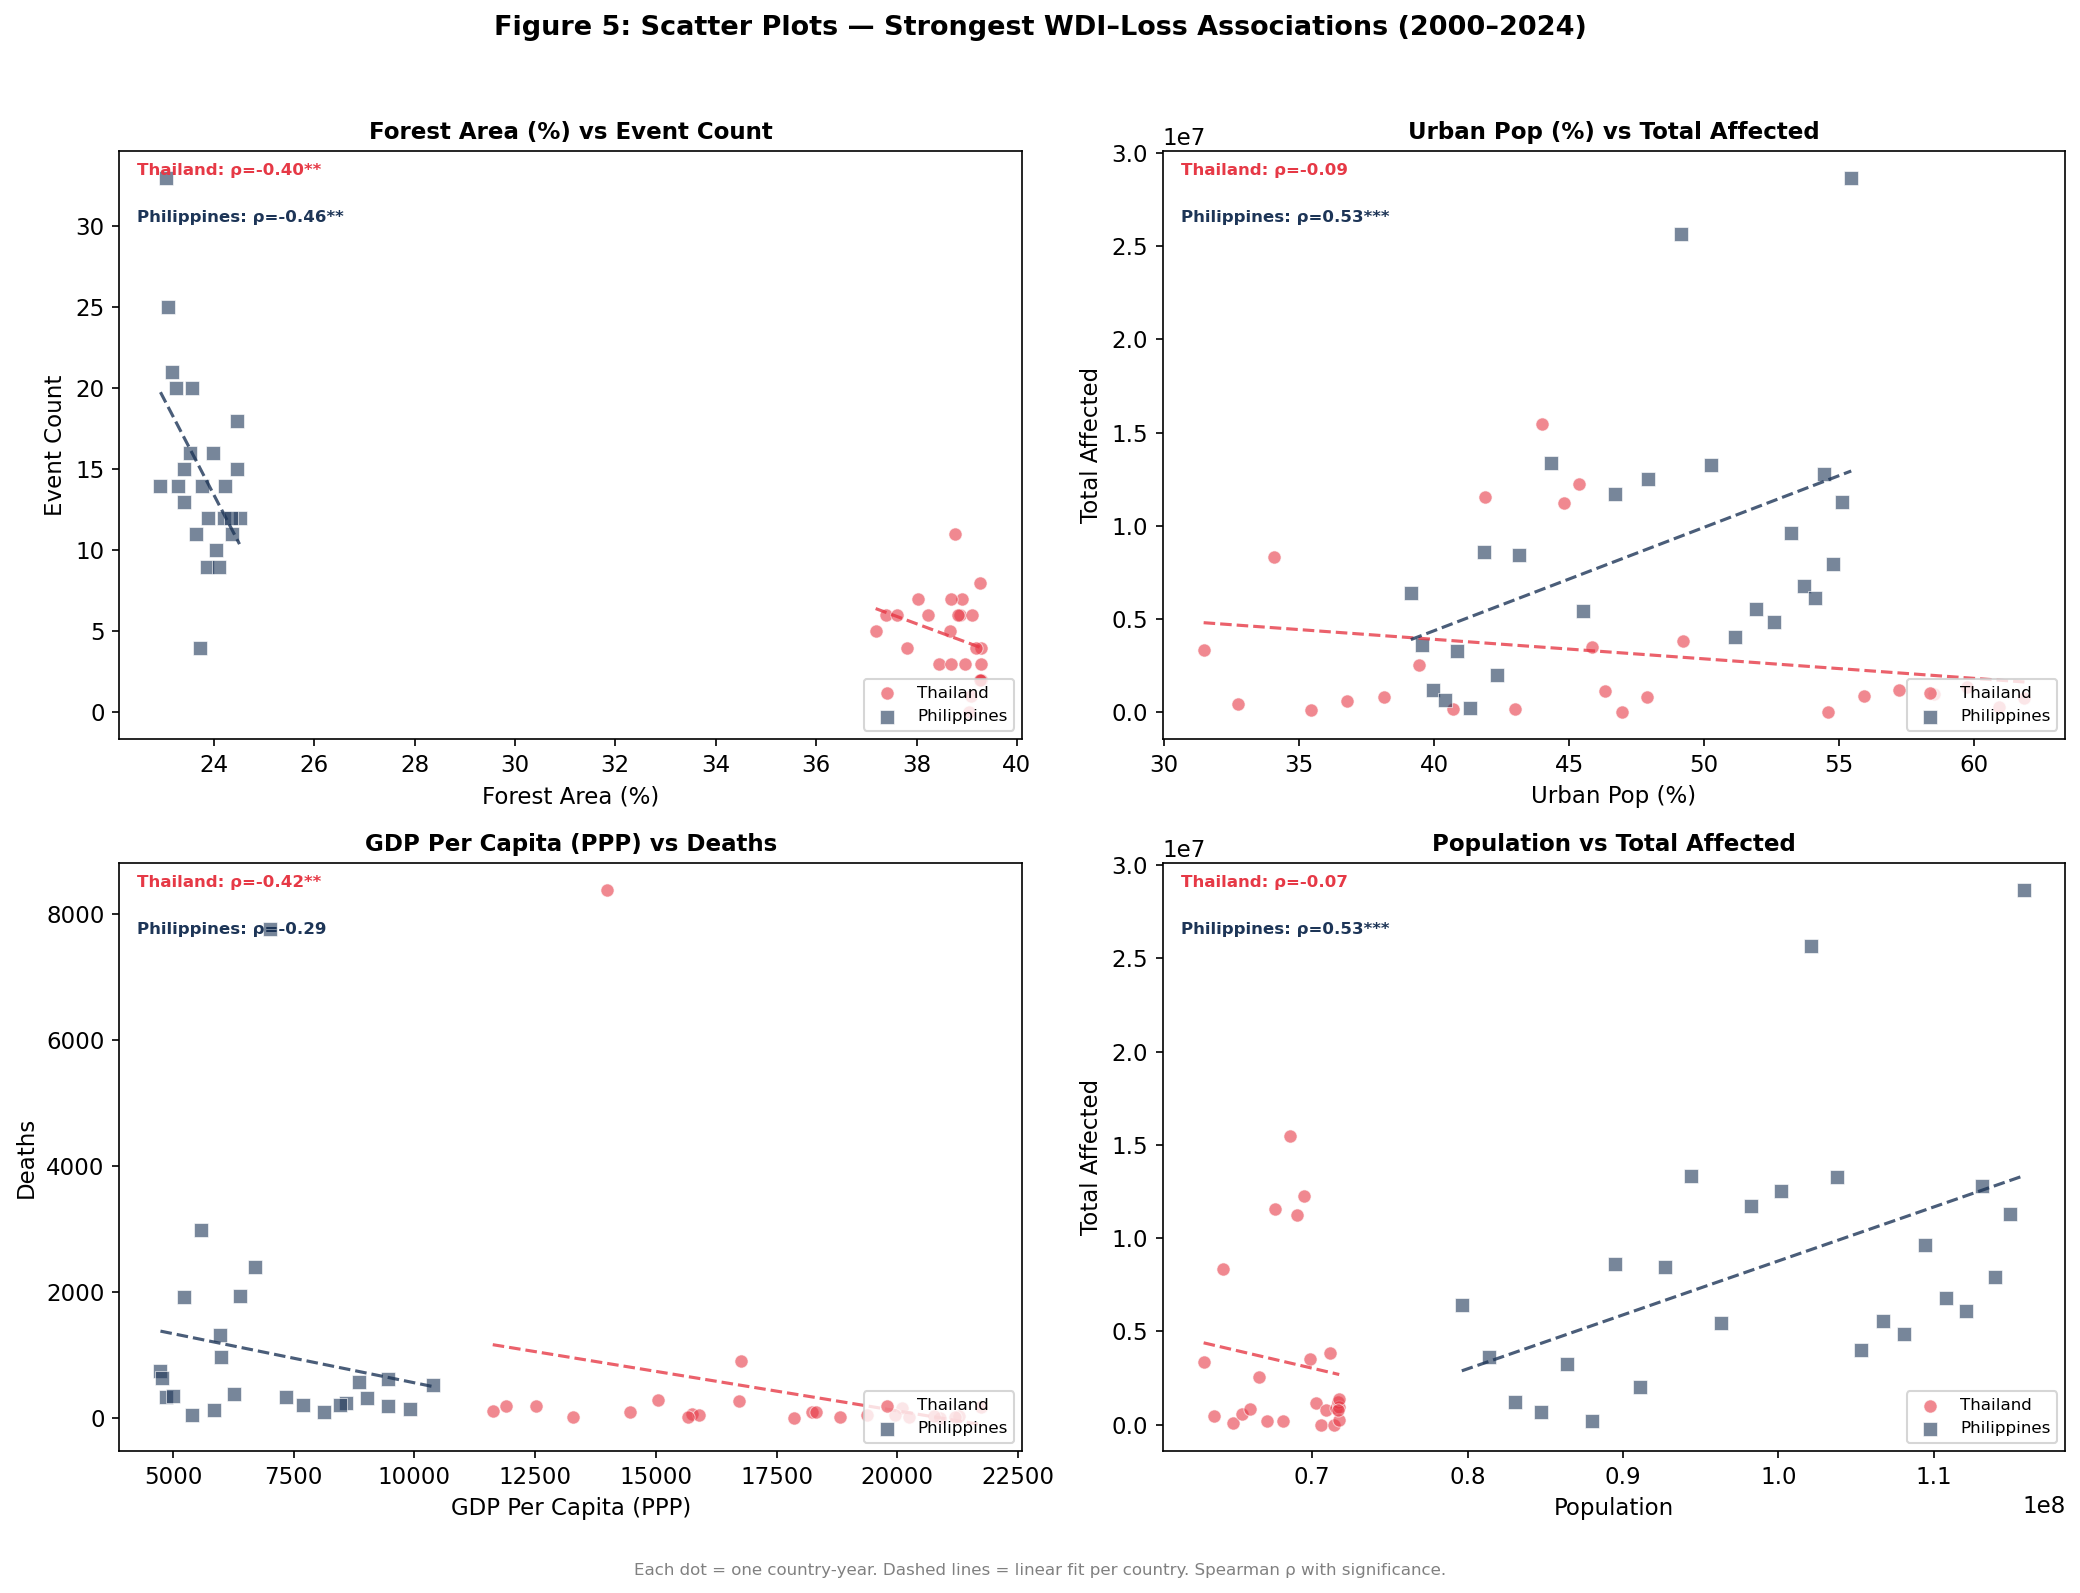

In [18]:
Scatter_Pairs = [
    ('Forest_%',           'Event_Count',      'Forest Area (%)',      'Event Count'),
    ('Urban_%',            'Total_Affected',    'Urban Pop (%)',        'Total Affected'),
    ('GDP_Per_Capita_PPP', 'Total_Deaths',      'GDP Per Capita (PPP)', 'Deaths'),
    ('Population',         'Total_Affected',    'Population',           'Total Affected'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (Wdi_Col, Out_Col, X_Label, Y_Label) in enumerate(Scatter_Pairs):
    ax = axes.flatten()[idx]
    
    for Country, Sub, Color, Marker in [
        ('Thailand',    THA, Colors['Thailand'],    'o'),
        ('Philippines', PHL, Colors['Philippines'],  's'),
    ]:
        Valid = Sub[[Wdi_Col, Out_Col]].dropna()
        if len(Valid) < 3:
            continue
        
        ax.scatter(Valid[Wdi_Col], Valid[Out_Col], color=Color, marker=Marker,
                   s=40, alpha=0.6, label=Country, edgecolors='white', linewidth=0.5)
        
        # Regression line
        x = Valid[Wdi_Col].values
        y = Valid[Out_Col].values
        z = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, np.polyval(z, x_line), '--', color=Color, linewidth=1.5, alpha=0.8)
        
        # Spearman correlation annotation
        r, p = stats.spearmanr(x, y)
        Star = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
        ax.annotate(f'{Country}: ρ={r:.2f}{Star}',
                    xy=(0.02, 0.98 - 0.08 * (0 if Country == 'Thailand' else 1)),
                    xycoords='axes fraction', fontsize=8, color=Color,
                    verticalalignment='top', fontweight='bold')
    
    ax.set_xlabel(X_Label)
    ax.set_ylabel(Y_Label)
    ax.set_title(f'{X_Label} vs {Y_Label}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('Figure 5: Scatter Plots — Strongest WDI–Loss Associations (2000–2024)',
             fontweight='bold', fontsize=13, y=1.02)
plt.figtext(0.5, -0.02,
    'Each dot = one country-year. Dashed lines = linear fit per country. Spearman ρ with significance.',
    ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig(Output_WS3 / 'WS3_Scatter_WDI_Loss.png')
plt.show()

## Step 5: Portfolio Implications & Summary Dashboard

### Figure 6: Summary Dashboard

A 6-panel dashboard synthesising the key metrics for the reinsurer. 
* The top row shows disaster outcomes. 
* The bottom row shows the three recommended monitoring indicators from WS2/WS3.

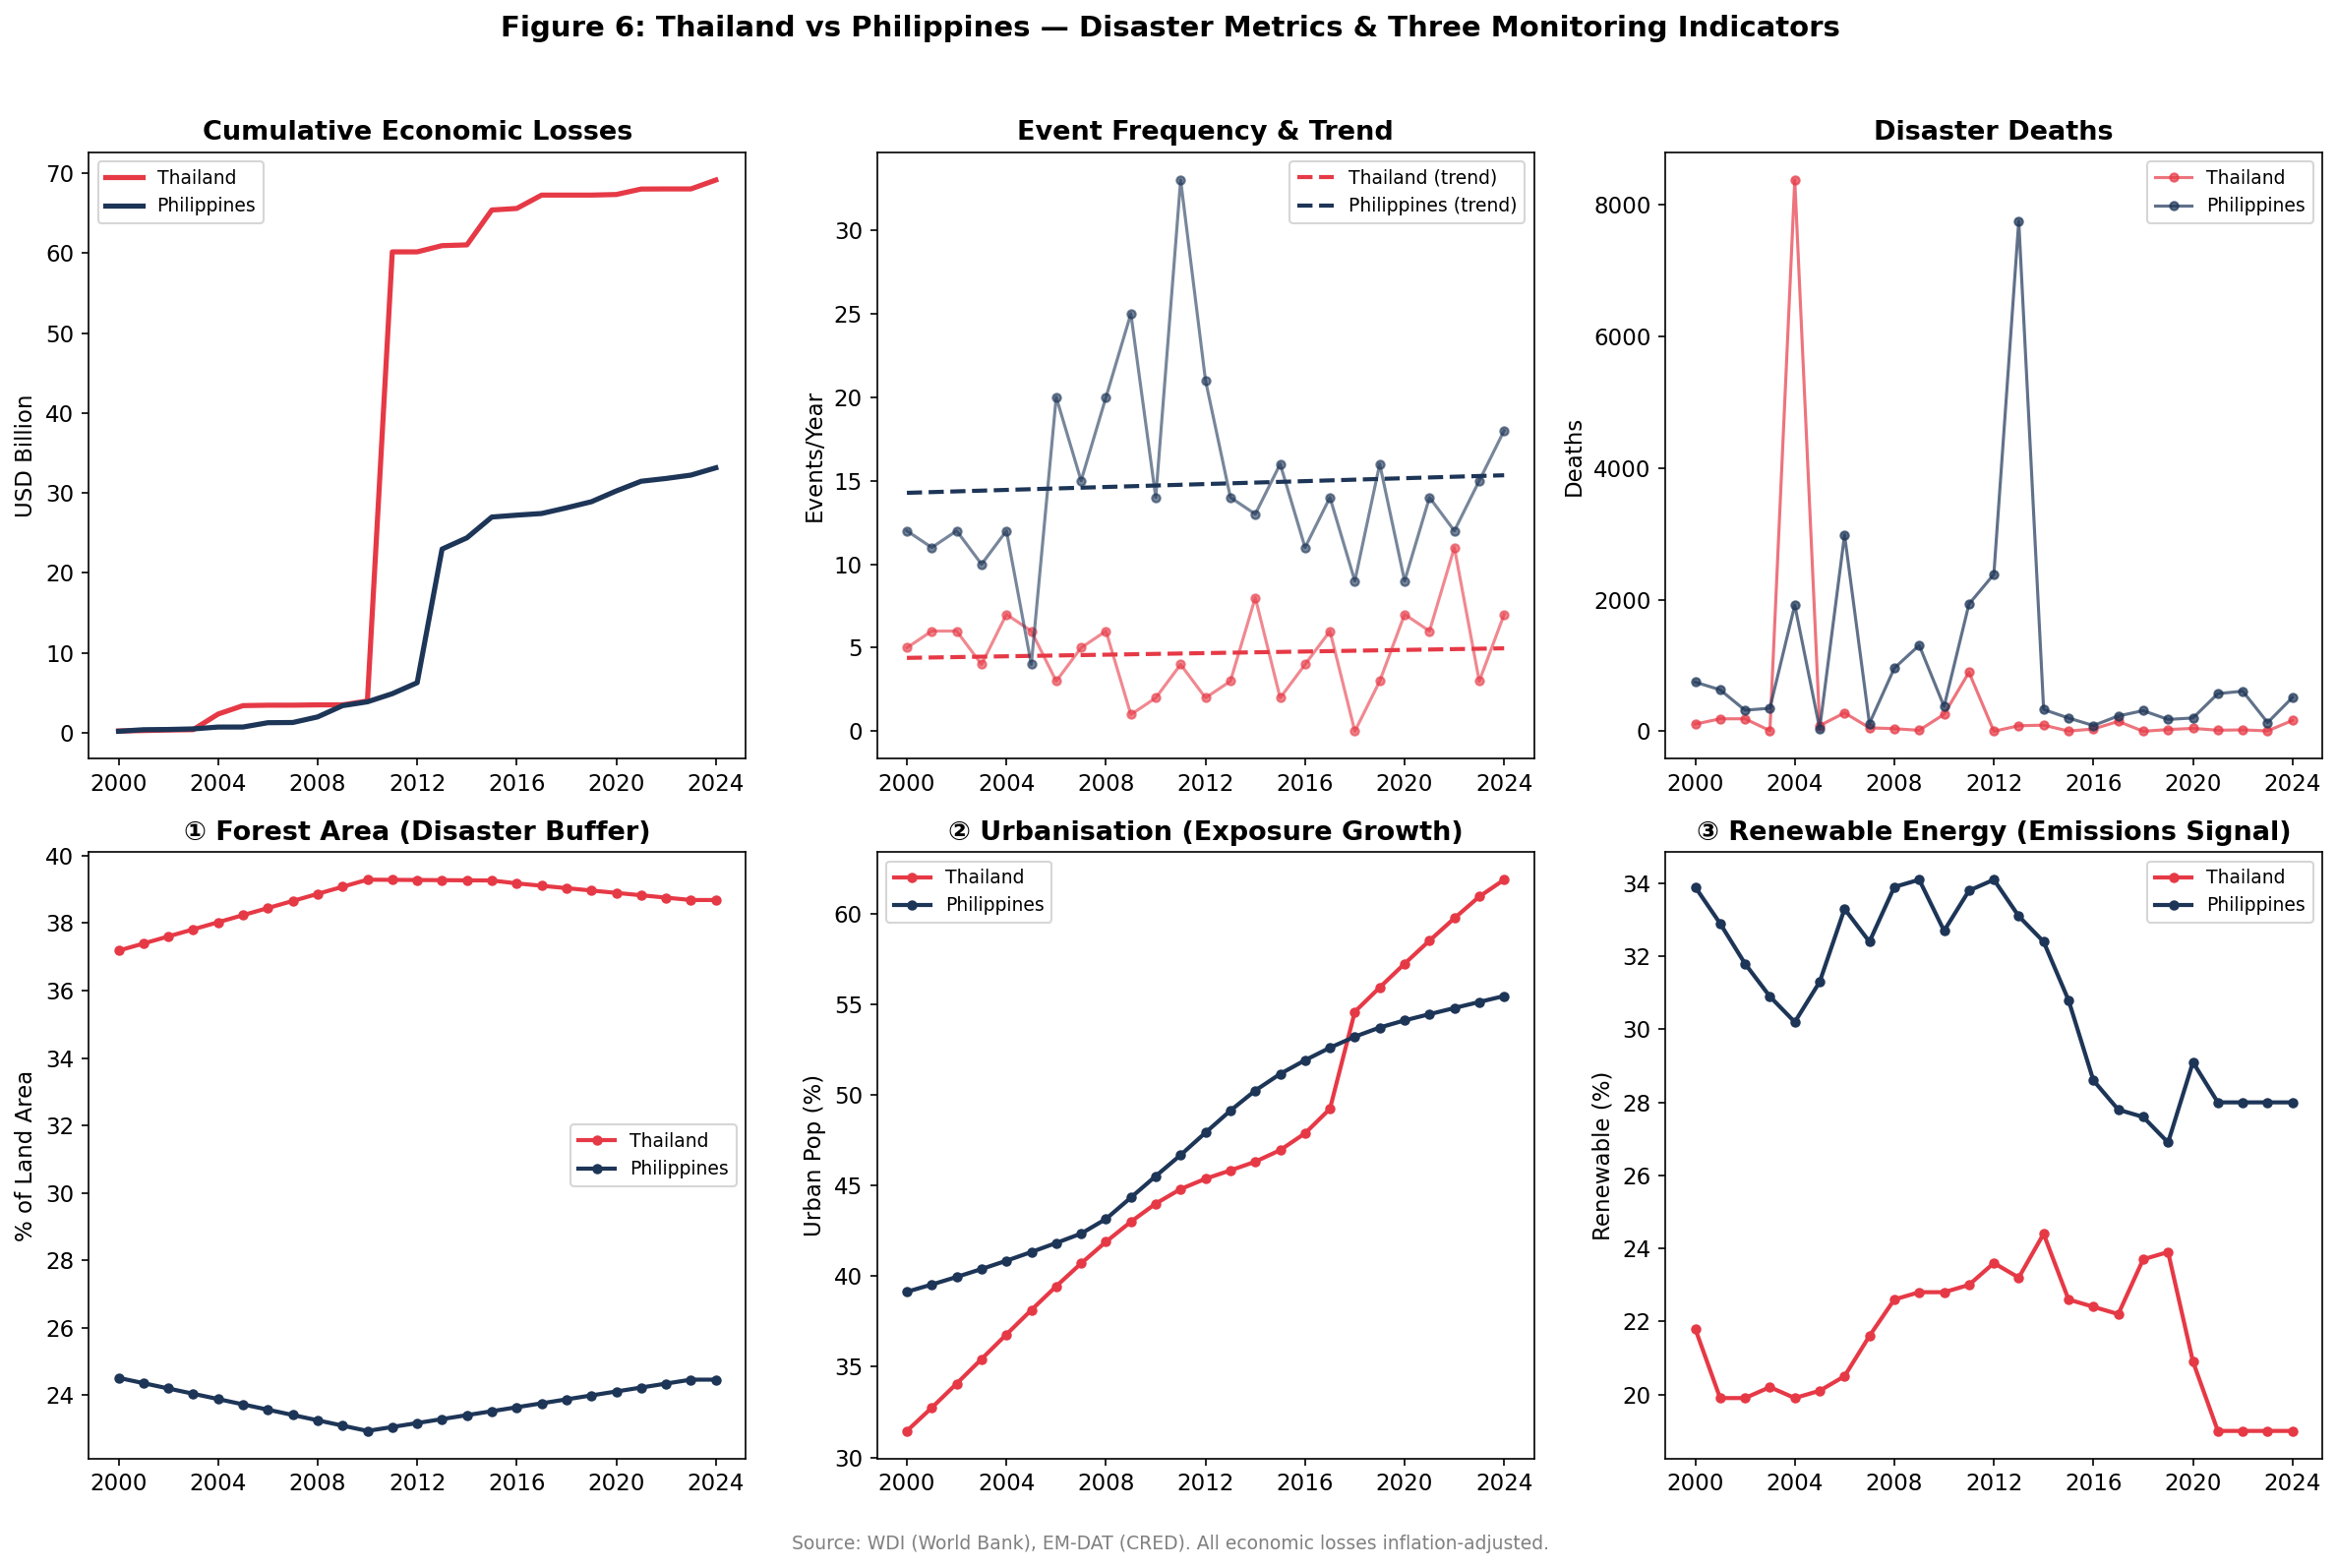

In [19]:
# ============================================================
# FIGURE 6: Summary Dashboard
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── Row 1: Disaster Outcomes ─────────────────────────────────

# 1. Cumulative losses
ax = axes[0, 0]
for c, sub, col in [('Thailand', THA, Colors['Thailand']), ('Philippines', PHL, Colors['Philippines'])]:
    s = sub.sort_values('Year')
    ax.plot(s['Year'], s['Econ_Loss_Adj_M'].cumsum() / 1000, '-', color=col, linewidth=2.5, label=c)
ax.set_title('Cumulative Economic Losses', fontweight='bold'); ax.set_ylabel('USD Billion'); ax.legend(fontsize=9)
ax.set_xticks(range(2000, 2025, 4))

# 2. Event frequency with trend
ax = axes[0, 1]
for c, sub, col in [('Thailand', THA, Colors['Thailand']), ('Philippines', PHL, Colors['Philippines'])]:
    s = sub.sort_values('Year')
    ax.plot(s['Year'], s['Event_Count'], 'o-', color=col, linewidth=1.5, markersize=4, alpha=0.6)
    z = np.polyfit(s['Year'], s['Event_Count'], 1)
    ax.plot(s['Year'], np.polyval(z, s['Year']), '--', color=col, linewidth=2, label=f'{c} (trend)')
ax.set_title('Event Frequency & Trend', fontweight='bold'); ax.set_ylabel('Events/Year'); ax.legend(fontsize=9)
ax.set_xticks(range(2000, 2025, 4))

# 3. Deaths trend (replaces Loss per Event)
ax = axes[0, 2]
for c, sub, col in [('Thailand', THA, Colors['Thailand']), ('Philippines', PHL, Colors['Philippines'])]:
    s = sub.sort_values('Year')
    ax.plot(s['Year'], s['Total_Deaths'], 'o-', color=col, linewidth=1.5, markersize=4, alpha=0.7, label=c)
ax.set_title('Disaster Deaths', fontweight='bold'); ax.set_ylabel('Deaths'); ax.legend(fontsize=9)
ax.set_xticks(range(2000, 2025, 4))

# ── Row 2: Three Monitoring Indicators (from WS2/WS3) ────────

# 4. Forest Area
ax = axes[1, 0]
for c, sub, col in [('Thailand', THA, Colors['Thailand']), ('Philippines', PHL, Colors['Philippines'])]:
    s = sub.sort_values('Year')
    v = s[s['Forest_%'].notna()]
    ax.plot(v['Year'], v['Forest_%'], 'o-', color=col, linewidth=2, markersize=4, label=c)
ax.set_title('\u2460 Forest Area (Disaster Buffer)', fontweight='bold'); ax.set_ylabel('% of Land Area'); ax.legend(fontsize=9)
ax.set_xticks(range(2000, 2025, 4))

# 5. Urban Population
ax = axes[1, 1]
for c, sub, col in [('Thailand', THA, Colors['Thailand']), ('Philippines', PHL, Colors['Philippines'])]:
    s = sub.sort_values('Year')
    ax.plot(s['Year'], s['Urban_%'], 'o-', color=col, linewidth=2, markersize=4, label=c)
ax.set_title('\u2461 Urbanisation (Exposure Growth)', fontweight='bold'); ax.set_ylabel('Urban Pop (%)'); ax.legend(fontsize=9)
ax.set_xticks(range(2000, 2025, 4))

# 6. Renewable Energy
ax = axes[1, 2]
for c, sub, col in [('Thailand', THA, Colors['Thailand']), ('Philippines', PHL, Colors['Philippines'])]:
    s = sub.sort_values('Year')
    v = s[s['Renewable_%'].notna()]
    ax.plot(v['Year'], v['Renewable_%'], 'o-', color=col, linewidth=2, markersize=4, label=c)
ax.set_title('\u2462 Renewable Energy (Emissions Signal)', fontweight='bold'); ax.set_ylabel('Renewable (%)'); ax.legend(fontsize=9)
ax.set_xticks(range(2000, 2025, 4))

fig.suptitle('Figure 6: Thailand vs Philippines \u2014 Disaster Metrics & Three Monitoring Indicators',
             fontweight='bold', fontsize=14, y=1.02)
plt.figtext(0.5, -0.02, 'Source: WDI (World Bank), EM-DAT (CRED). All economic losses inflation-adjusted.',
            ha='center', fontsize=9, color='gray')
plt.tight_layout()
plt.savefig(Output_WS3 / 'WS3_Summary_Dashboard.png')
plt.show()

## Step 6: Export

Save outputs for the dashboard. 

In [20]:
# 1. Merged panel dataset (for dashboard and submission)
Panel.to_csv(Data_Path / 'WS3_Panel_THA_PHL.csv', index=False)

# 2. Protection gap data (for dashboard)
Gap_Export = pd.concat([
    THA_Gap[['Country', 'Year', 'Econ_Loss_Adj_M', 'Insured_Est_M', 'Uninsured_M', 'Insured_Ratio']],
    PHL_Gap[['Country', 'Year', 'Econ_Loss_Adj_M', 'Insured_Est_M', 'Uninsured_M', 'Insured_Ratio']]
])
Gap_Export.to_csv(Data_Path / 'WS3_Protection_Gap.csv', index=False)

# 3. Correlation results (for dashboard/report reference)
Sig_Df.to_csv(Data_Path / 'WS3_Significant_Correlations.csv', index=False)

print('=' * 60)
print('     STEP 6: EXPORTS SAVED')
print('=' * 60)
print(f'  1. {Data_Path / "WS3_Panel_THA_PHL.csv"}')
print(f'     Shape: {Panel.shape}')
print(f'  2. {Data_Path / "WS3_Protection_Gap.csv"}')
print(f'     Shape: {Gap_Export.shape}')
print(f'  3. {Data_Path / "WS3_Significant_Correlations.csv"}')
print(f'     Significant correlations: {len(Sig_Df)}')

     STEP 6: EXPORTS SAVED
  1. /Users/entong/Desktop/MASAHKT2026/Model/Data/WS3_Panel_THA_PHL.csv
     Shape: (50, 29)
  2. /Users/entong/Desktop/MASAHKT2026/Model/Data/WS3_Protection_Gap.csv
     Shape: (50, 6)
  3. /Users/entong/Desktop/MASAHKT2026/Model/Data/WS3_Significant_Correlations.csv
     Significant correlations: 15


## Limitations

1. **Sparse insured loss data.** Only ~11 of 502 EM-DAT events have insured values. Protection gap estimates use published aggregate ratios (Swiss Re, Munich Re), not observed claims.

2. **2011 Thai flood outlier.** One event = 81% of all Thai losses. Distorts all Thailand economic loss correlations.

3. **Correlation ≠ causation.** Results identify co-movements and leading indicators, not causal mechanisms.

4. **Macro-level annual data only.** WDI cannot capture sub-annual weather patterns or within-country spatial variation.

5. **Small sample (n=25 per country).** Limits statistical power; ρ ≈ 0.40–0.50 is the practical ceiling.

6. **No COVID adjustment.** 2020–2021 data may reflect pandemic disruption rather than climate dynamics.

## References

| # | Source |
|---|--------|
| 1 | Swiss Re (2021). "A decade on, learning from Thailand's devastating 2011 floods." |
| 2 | Munich Re (2025). "Natural disaster figures 2024." Media Information, January 2025. |
| 3 | EM-DAT / CRED (2025). The Emergency Events Database. Universit\u00e9 catholique de Louvain. |
| 4 | A.M. Best (2012). "Best Analyzes Impact of Flood Losses on Thai Insurance Industry." |
| 5 | MAPFRE Economics (2025). Natural Catastrophe Insurance Protection Gap. COP30. |
| 6 | Fortune / Munich Re (2026). "Asia is one of the world's least insured places." |
| 7 | OECD (2026). "OECD backs mandatory home insurance amid rising Philippine disaster losses." |
| 8 | Insurance Business Asia (2026). "Philippines builds insurance buffer as climate shocks intensify." |
| 9 | GlobalData (2026). "Philippines Property Insurance Forecast 2026\u20132030." |
| 10 | World Bank (2024). "Disaster risk insurance: 5 insights from the Philippines." |
| 11 | World Bank WDI (2025). World Development Indicators. Wide Format. |
| 12 | Lloyd's of London (2012). "Thailand flooding: one year on." Emerging Risks Report. |
| 13 | Dietz, T. and Rosa, E.A. (1997). "Effects of population and affluence on CO\u2082 emissions." PNAS. |

## WS3 Complete — Handoff to WS5

**Country pair:** Thailand vs Philippines
<br> **Key findings:**
1. Thailand: Concentrated tail risk (2011 floods dominate); 
    <br> Philippines: Attritional frequency risk with tail events (370+ events, 96% protection gap)

2. Exposure drivers (Urban %, Forest %, GDP/cap, Population) show stronger WDI–loss associations than emissions drivers (Energy/cap, Renewable %), even after normalising per predictor (2.8 vs 1.5 significant pairs per predictor)

3. Three monitoring indicators recommended: Forest Area %, Urban Pop %, Renewable Energy %

**For Report & Dashboard:**
1. `WS3_Panel_THA_PHL.csv` — merged WDI + EM-DAT panel
2. `WS3_Protection_Gap.csv` — insured vs uninsured loss estimates
3. `WS3_Significant_Correlations.csv` — significant Spearman correlations
4. Figures 1–6 saved in `Output_WS3/`